In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR
from scipy.io import savemat, loadmat
import os


In [2]:
class SpatialFourierNN(nn.Module):
    def __init__(self, hidden_dim=128, num_frequencies=16, scale=10.0):
        super().__init__()
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            self.device = torch.device("mps")
        else:
            self.device = torch.device("cpu")

        
        self.num_frequencies = num_frequencies
        self.scale = scale

        # Frequencies for Fourier feature encoding
        self.B = nn.Parameter(
            torch.randn((num_frequencies, 1)) * scale, requires_grad=False
        )

        self.net = nn.Sequential(
            nn.Linear(2 * num_frequencies, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

#     def fourier_features(self, x):
#         # x: shape (batch_size, 1)
#         x_proj = 2 * np.pi * x @ self.B.T  # shape: (batch_size, num_frequencies)
#         return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
    def fourier_features(self, x):
        B = self.B.to(x.device)  # Move B to same device as x
        x_proj = 2 * np.pi * x @ B.T
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

    def forward(self, x):
        x_encoded = self.fourier_features(x)
        return self.net(x_encoded).squeeze(-1)


In [3]:
class Trainer:
    def __init__(self, U2, x_ten, SpatialNN, batch_size=32, lr=5e-4, max_lr=5e-3, lambda_lr=5e-3):
        # Automatically choose device: CUDA > MPS > CPU
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            self.device = torch.device("mps")
        else:
            self.device = torch.device("cpu")

        self.U2 = U2.to(self.device)                  
        self.x_ten = x_ten.to(self.device)            
        self.dataset = TensorDataset(self.x_ten, self.U2)
        self.batch_size = batch_size
        self.dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)

        self.model_phi = SpatialNN().to(self.device)
        self.lambda_ten = nn.Parameter(torch.ones(U2.shape[1], device=self.device))  # (M,)

        # Parameter groups for different training behavior
        self.optimizer = optim.AdamW([
            {"params": self.model_phi.parameters(), "lr": lr, "weight_decay": 1e-2},
            {"params": [self.lambda_ten], "lr": lambda_lr, "weight_decay": 0.0}
        ])

        self.loss_fn = nn.MSELoss()
        self.lr = lr
        self.max_lr = max_lr
        self.lambda_lr = lambda_lr

    def train(self, num_epochs=40000):
        steps_per_epoch = len(self.dataloader)

        self.scheduler = OneCycleLR(
            self.optimizer,
            max_lr=self.max_lr,
            epochs=num_epochs,
            steps_per_epoch=steps_per_epoch,
            anneal_strategy='cos',
            pct_start=0.1,
            div_factor=25.0
        )

        for epoch in range(num_epochs):
            self.model_phi.train()
            epoch_loss = 0.0

            for x_batch, u_batch in self.dataloader:
                x_batch = x_batch.to(self.device)
                u_batch = u_batch.to(self.device)

                self.optimizer.zero_grad()

                f_x = self.model_phi(x_batch)                      # (B,)
                pred = torch.outer(f_x, self.lambda_ten)           # (B, M)

                loss = self.loss_fn(pred, u_batch)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    list(self.model_phi.parameters()) + [self.lambda_ten], max_norm=1.0
                )

                self.optimizer.step()
                self.scheduler.step()

                epoch_loss += loss.item()

            if epoch % 100 == 0:
                avg_loss = epoch_loss / steps_per_epoch
                print(f"[{epoch:04d}] Loss: {avg_loss:.4e}")

        return self.model_phi, self.lambda_ten


In [4]:
def run_fnpod(k, x_ten, U_tensor, vs, x, epoch_num):
    # Automatically determine device
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    x_ten = x_ten.to(device)
    U_tensor = U_tensor.to(device)

    mat_filename = f'fnpod_phi{k}.mat'
    weight_filename = f'fnpod_phi{k}_weights.pth'

    if os.path.exists(mat_filename) and os.path.exists(weight_filename):
        # Load saved data and model
        data_phi = loadmat(mat_filename, variable_names=['lambda'])
        lambdak = data_phi['lambda']

        model_phik = SpatialFourierNN().to(device)
        model_phik.load_state_dict(torch.load(weight_filename, map_location=device))
        model_phik.eval()

        with torch.no_grad():
            phik = model_phik(x_ten).cpu().numpy()
            phik_tensor = model_phik(x_ten)          # still a tensor
            phik_np = phik_tensor.cpu().numpy()      # convert once here
            U_recon = np.outer(phik_np, lambdak)

#             U_recon = np.outer(phik, lambdak)
#             phik_np = phik.cpu().numpy()
            
        # L2 normalization
        l2_fnpod_phik = np.sqrt(np.trapz(phik_np**2, x))
        l2_pod_phik = np.sqrt(np.trapz(vs**2, x))

        phik_npod = phik_np / l2_fnpod_phik
        phik_pod = vs / l2_pod_phik

        return U_recon, phik_npod, phik_pod, lambdak

    else:
        # Train the model
        trainer = Trainer(
            U_tensor, x_ten, SpatialFourierNN,
            batch_size=64,
            lr=5e-4,
            lambda_lr=1e-2
        )
        model_phik, lambdak_ten = trainer.train(num_epochs=epoch_num)

        loss_list_phik = []

        with torch.no_grad():
            phik = model_phik(x_ten)  # shape: (n, r)
            phik_np = phik.cpu().numpy()
            lambdak_np = lambdak_ten.detach().cpu().numpy()
            U_recon = np.outer(phik_np, lambdak_np)

            U_recon_torch = torch.from_numpy(U_recon).float().to(device)
            loss = torch.nn.functional.mse_loss(U_recon_torch, U_tensor)
            loss_list_phik.append(loss.item())

        # L2 normalization
        l2_fnpod_phik = np.sqrt(np.trapz(phik_np**2, x))
        l2_pod_phik = np.sqrt(np.trapz(vs**2, x))

        phik_npod = phik_np / l2_fnpod_phik
        phik_pod = vs / l2_pod_phik

        # Save data and model
        data_to_save = {
            'x': x,
            'lambda': lambdak_np,
            'l2_npod': l2_fnpod_phik,
            'l2_pod': l2_pod_phik,
            'phi_fnpod': phik_npod,
            'phi_pod': phik_pod,
            'loss_list_phi': loss_list_phik
        }
        savemat(mat_filename, data_to_save)
        torch.save(model_phik.state_dict(), weight_filename)

        return U_recon, phik_npod, phik_pod, lambdak_ten



load Burgers equation code

In [5]:
mat_file_path = '/home/mouc/neural-pod/Burger.mat'  # Replace with the actual path to your .mat file
data = loadmat(mat_file_path)

print(data.keys())  # Check variable names

u_dataset = data['output']

dict_keys(['__header__', '__version__', '__globals__', 'gamma', 'input', 'output', 'sigma', 'tau', 'tspan'])


extract the solution of burgers equations

In [6]:
# u_data has shape (n1, n2, n3)
u_soln_par = u_dataset[0, :, :]  # shape (n2, n3)

# Given: u_soln is an array of shape (n1, n2, n3)
u_mean = np.mean(u_soln_par, axis=0)  # u_mean will have shape (n2, n3)

# Subtract the mean from u_soln. Broadcasting automatically subtracts
u_soln = u_soln_par - u_mean
# u_soln = u_soln_par 
# print(u_soln.shape)



revise to find the POD solution to the data set u_soln

In [7]:
# Assume snap is a NumPy array
us, s, vh = np.linalg.svd(u_soln, full_matrices=True)
# Convert the singular values to a diagonal matrix to match MATLAB's output:
sig = np.diag(s)
# Transpose vh to get vs (because MATLAB returns V, not V^T)
vs = vh.T

prepare for data sets

In [8]:
# Generate data
x = np.linspace(0, 1, 1001)
t = np.linspace(0, 1, 101)
X, T = np.meshgrid(x, t)

x_ten = torch.tensor(x, dtype=torch.float32).view(-1, 1)      # (N=1001, 1)
U1 = torch.tensor(u_soln.T, dtype=torch.float32)              # Transpose to (N, M)


In [9]:
x_ten = torch.tensor(x, dtype=torch.float32).view(-1, 1)
# U_tensor = torch.tensor(u_soln.T, dtype=torch.float32)
k = 1
epoch_num = 1000
U1_recon, phi1_fnpod, phi1_pod, lambda1_ten = run_fnpod(k, x_ten, U1, vs[:,k-1], x,epoch_num)


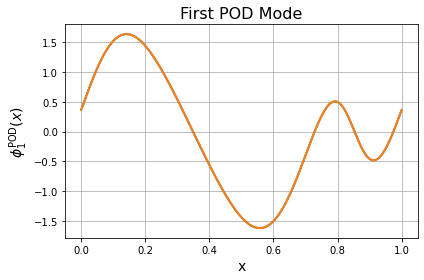

In [10]:
import numpy as np

plt.figure(figsize=(6, 4))
plt.plot(x, phi1_fnpod, linewidth=2)
plt.plot(x, phi1_pod, linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel(r'$\phi_1^{\mathrm{POD}}(x)$', fontsize=14)
plt.title('First POD Mode', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:

U1_recon_torch = torch.from_numpy(U1_recon).float()

U2 = U1- U1_recon_torch            # Transpose to (N, M)

k = 2
epoch_num=5000
U2_recon, phi2_fnpod, phi2_pod, lambda2_ten= run_fnpod(k, x_ten, U2, vs[:,k-1], x,epoch_num)



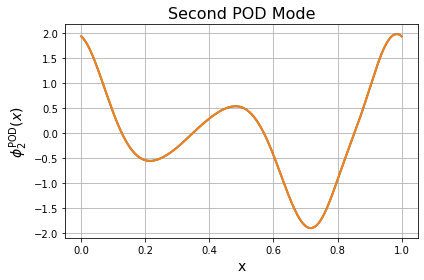

In [12]:
import numpy as np

plt.figure(figsize=(6, 4))
plt.plot(x, phi2_fnpod, linewidth=2)
plt.plot(x, -phi2_pod, linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel(r'$\phi_2^{\mathrm{POD}}(x)$', fontsize=14)
plt.title('Second POD Mode', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
U2_recon_torch = torch.from_numpy(U2_recon).float()

U3 = U2- U2_recon_torch            # Transpose to (N, M)

k = 3
epoch_num=5000
U3_recon, phi3_fnpod, phi3_pod, lambda3_ten= run_fnpod(k, x_ten, U3, vs[:,k-1], x,epoch_num)


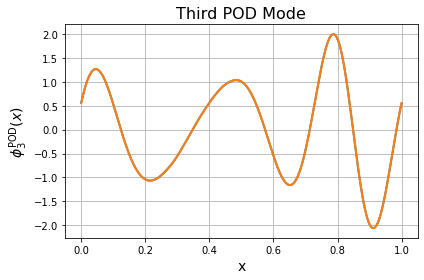

In [14]:
import numpy as np

plt.figure(figsize=(6, 4))
plt.plot(x, phi3_fnpod, linewidth=2)
plt.plot(x, -phi3_pod, linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel(r'$\phi_3^{\mathrm{POD}}(x)$', fontsize=14)
plt.title('Third POD Mode', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


In [15]:
U3_recon_torch = torch.from_numpy(U3_recon).float()

U4 = U3- U3_recon_torch            # Transpose to (N, M)

k = 4
epoch_num=5000
U4_recon, phi4_fnpod, phi4_pod, lambda4_ten= run_fnpod(k, x_ten, U4, vs[:,k-1], x,epoch_num)


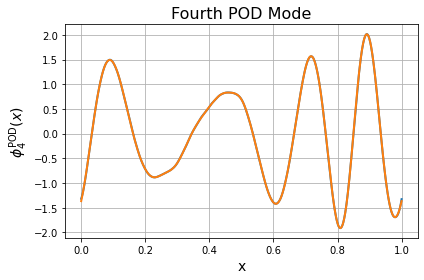

In [16]:
import numpy as np

plt.figure(figsize=(6, 4))
plt.plot(x, phi4_fnpod, linewidth=2)
plt.plot(x, phi4_pod, linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel(r'$\phi_4^{\mathrm{POD}}(x)$', fontsize=14)
plt.title('Fourth POD Mode', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()
